In [42]:
#========================================================================
#
# Name: financial-markets.ipynb
#
# Date: 21/06/2025
#
# Author: MT
# 
# Description: Financial Markets Data from Yahoo Finance
# https://uk.finance.yahoo.com/
#
# Steps:
# Step 0: Imports
# Step 1: Read Data from Yahoo Finance
# Step 2: Process Data
# Step 3: Augmented Dickey-Fuller Test for Stationarity
# Step 4: Make Plots
#
#========================================================================

In [43]:
#========================================================================
# Step 0: Imports

# Pandas and Numpy
import pandas as pd
import numpy as np

# Yahoo Finance
import yfinance as yf

# Dickey-Fuller test for stationarity
from statsmodels.tsa.stattools import adfuller

# Matplotlib and Seaborn
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
import seaborn as sns
sns.set_theme(style="whitegrid")

# Copy
import copy
#========================================================================

In [44]:
#========================================================================
# Step 1: Read Data from Yahoo Finance

# Define dates
start_date = "1984-01-01"
end_date = "2027-01-01"

# Download the historical data
def get_data(ticker, start_date, end_date):
    """Extracts historical data for a given ticker from Yahoo Finance."""

    # Download data from Yahoo Finance
    data = yf.download(ticker, start=start_date, end=end_date).reset_index().iloc[:, [0, 1,5]]
    data.columns = ['Date', 'Close', 'Volume']
    data['ticker'] = ticker.replace("^", "")
    data=data[['ticker', 'Date', 'Close', 'Volume']]

    # Last trading day of the year
    data['year']=data['Date'].dt.year
    data['year_lead']=data['year'].shift(-1)
    data['last_trading_day']=data['year_lead']-data['year']
    data.drop(columns=['year', 'year_lead'], inplace=True)
    return data

#USA
# Download S&P 500 data
df_GSPC = get_data(ticker ="^GSPC", start_date=start_date, end_date=end_date)

# Download Dow Jones Industrial Average data
df_DJI = get_data(ticker ="^DJI", start_date=start_date, end_date=end_date)

# Download NASDAQ Composite data
df_NDX = get_data(ticker ="^IXIC", start_date=start_date, end_date=end_date)

# Download Russell 2000 data
df_RUT = get_data(ticker ="^RUT", start_date=start_date, end_date=end_date)


# Europe

# Download FTSE 100 data
df_FTSE = get_data(ticker ="^FTSE", start_date=start_date, end_date=end_date)

# Download DAX data
df_DAX = get_data(ticker ="^GDAXI", start_date=start_date, end_date=end_date)

# Download CAC 40 data
df_CAC = get_data(ticker ="^FCHI", start_date=start_date, end_date=end_date)

# Download Euronext 100 data
df_N100 = get_data(ticker ="^N100", start_date=start_date, end_date=end_date)


# Asia

# Download ASX 200 data
df_ASX = get_data(ticker ="^AXJO", start_date=start_date, end_date=end_date)

# Download Nikkei 225 data
df_N225 = get_data(ticker ="^N225", start_date=start_date, end_date=end_date)

# Download Hang Seng Index data
df_HSI = get_data(ticker ="^HSI", start_date=start_date, end_date=end_date)

# Download Shanghai Stock Exchange Composite Index data
df_SSEC = get_data(ticker ="000001.SS", start_date=start_date, end_date=end_date)    
#========================================================================

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [45]:
#========================================================================
# Step 2: Process Data

def process_financial_data(df_list):
    """
    Filters dataframes by 'last_trading_day' and calculates percentage returns.
    Returns a list of processed dataframes.
    """
    processed_dfs = []
    
    for df in df_list:
        # Create a deep copy of the filtered dataframe
        new_df = copy.deepcopy(df[df['last_trading_day'] == 1])
        
        # Calculate the returns
        new_df['Return'] = new_df['Close'].pct_change()
        
        processed_dfs.append(new_df)
        
    return processed_dfs

# Group your original dataframes into lists
usa_list = [df_GSPC, df_DJI, df_NDX, df_RUT]
eur_list = [df_FTSE, df_DAX, df_CAC, df_N100]
asia_list = [df_ASX, df_N225, df_HSI, df_SSEC]

# Call the function for each region
usa_processed = process_financial_data(usa_list)
eur_processed = process_financial_data(eur_list)
asia_processed = process_financial_data(asia_list)
#========================================================================

In [46]:
#========================================================================
# Step 3: Augmented Dickey-Fuller Test for Stationarity

def calculate_adf_statistics(data, name):
    """
    Calculates the Augmented Dickey-Fuller test statistics for 'Close' and 'Return' columns.
    Returns a DataFrame with the results.
    """
    result_Level  = adfuller(data['Close'].dropna())
    result_Return = adfuller(data['Return'].dropna())

    temp=pd.DataFrame({
        'Name': [name, name],
        'Series': ['Level', 'Return'],
        'ADF Statistic': [result_Level[0], result_Return[0]],
        'P-Value': [result_Level[1], result_Return[1]]
    })

    return temp

# USA ADF Statistics
usa0=calculate_adf_statistics(data=usa_processed[0], name='USA S&P 500')
usa1=calculate_adf_statistics(data=usa_processed[1], name='USA Dow Jones')
usa2=calculate_adf_statistics(data=usa_processed[2], name='USA NASDAQ')
usa3=calculate_adf_statistics(data=usa_processed[3], name='USA Russell 2000')

# Europe ADF Statistics
eur0 = calculate_adf_statistics(data=eur_processed[0], name='Europe FTSE 100')
eur1 = calculate_adf_statistics(data=eur_processed[1], name='Europe DAX')
eur2 = calculate_adf_statistics(data=eur_processed[2], name='Europe CAC 40')
eur3 = calculate_adf_statistics(data=eur_processed[3], name='Europe Euro Stoxx 100')

# Asia ADF Statistics
asia0 = calculate_adf_statistics(data=asia_processed[0], name='Asia ASX 200')
asia1 = calculate_adf_statistics(data=asia_processed[1], name='Asia Nikkei 225')
asia2 = calculate_adf_statistics(data=asia_processed[2], name='Asia Hang Seng')
asia3 = calculate_adf_statistics(data=asia_processed[3], name='Asia Shanghai Stock Exchange')

# Combine all ADF statistics into a single DataFrame
adf_statistics=pd.concat([usa0, usa1, usa2, usa3, eur0, eur1, eur2, eur3, asia0, asia1, asia2, asia3], ignore_index=True)
adf_statistics[['ADF Statistic', 'P-Value']] = adf_statistics[['ADF Statistic', 'P-Value']].round(4)
adf_statistics_Level  = adf_statistics[adf_statistics['Series']=='Level'].drop(columns=['Series'])
adf_statistics_Return = adf_statistics[adf_statistics['Series']=='Return'].drop(columns=['Series'])
#========================================================================

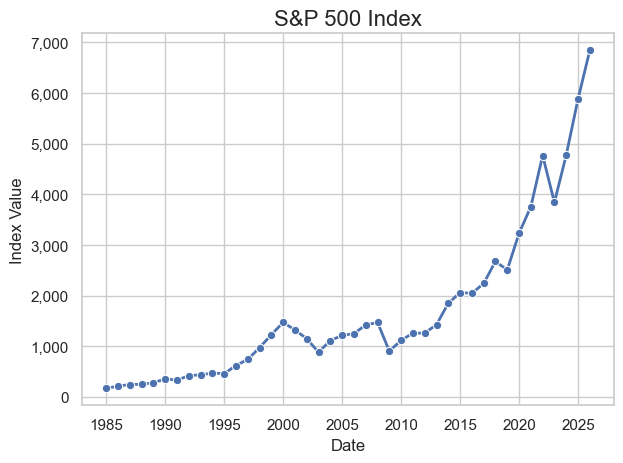

In [ ]:
#========================================================================
# Step 4: Make Plots

def make_plot(data, name,title1, title2):
    
    # Index Value Plot
    sns.lineplot(data=data, x='Date', y='Close', linewidth=2, marker='o')
    plt.title(title1, fontsize=16)
    plt.ylabel('Index Value', fontsize=12)
    plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    plt.tight_layout()
    plt.savefig(f"Index_{name}.png", dpi=300)
    plt.show()


    # Return Plot
    sns.lineplot(data=data, x='Date', y='Return', linewidth=2, marker='o')
    plt.title(title2, fontsize=16)

    # y-axis as percentage
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

    # Shade red where return is below 0
    plt.fill_between(data['Date'], data['Return'], 0, 
                    where=(data['Return'] < 0), 
                    color='red', alpha=0.5, interpolate=True)

    # Shade green where return is above 0
    plt.fill_between(data['Date'], data['Return'], 0, 
                    where=(data['Return'] >= 0), 
                    color='green', alpha=0.3, interpolate=True)

    # Add a horizontal line at y=0
    plt.axhline(0, color='black', linewidth=1, linestyle='--')

    # Calculate stats
    mean_ret = data['Return'].mean() * 100
    std_dev = data['Return'].std() * 100
    text_str = f"Mean Return: {mean_ret:.2f}%\nStd Deviation: {std_dev:.2f}%"
    plt.text(0.98, 0.05, text_str, transform=plt.gca().transAxes, 
            fontsize=12, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(f"Returns_{name}.png", dpi=300)
    plt.show()


    # Histogram Plot
    sns.histplot(data=data, x='Return')
    plt.title(f"{title2} Histogram", fontsize=16)
    plt.ylabel('Count', fontsize=12)
    plt.xlabel('Return', fontsize=12)
    plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    plt.tight_layout()
    plt.savefig(f"Histogram_{name}.png", dpi=300)
    plt.show()



# USA
make_plot(data=usa_processed[0], name='USA S&P 500',      title1='S&P 500 Index', title2='S&P 500 Annual Returns')
make_plot(data=usa_processed[1], name='USA Dow Jones',    title1='Dow Jones Industrial Average', title2='Dow Jones Annual Returns')
make_plot(data=usa_processed[2], name='USA NASDAQ',       title1='NASDAQ Composite Index', title2='NASDAQ Annual Returns')
make_plot(data=usa_processed[3], name='USA Russell 2000', title1='Russell 2000 Index', title2='Russell 2000 Annual Returns')


# Europe
make_plot(data=eur_processed[0], name='Europe FTSE 100',       title1='FTSE 100 Index', title2='FTSE 100 Annual Returns')
make_plot(data=eur_processed[1], name='Europe DAX',            title1='DAX Index', title2='DAX Annual Returns')
make_plot(data=eur_processed[2], name='Europe CAC 40',         title1='CAC 40 Index', title2='CAC 40 Annual Returns')
make_plot(data=eur_processed[3], name='Europe Euro Stoxx 100', title1='Euro Stoxx 100 Index', title2='Euro Stoxx 100 Annual Returns')

# Asia
make_plot(data=asia_processed[0], name='Asia ASX 200',                 title1='ASX 200 Index',title2='ASX 200 Annual Returns')
make_plot(data=asia_processed[1], name='Asia Nikkei 225',              title1='Nikkei 225 Index',title2='Nikkei 225 Annual Returns')
make_plot(data=asia_processed[2], name='Asia Hang Seng',               title1='Hang Seng Index',title2='Hang Seng Annual Returns')
make_plot(data=asia_processed[3], name='Asia Shanghai Stock Exchange', title1='Shanghai Stock Exchange Index',title2='Shanghai Stock Exchange Annual Returns')  
#========================================================================